 # Fase 1 — Analisi esplorativa del dataset Basket Action Recognition



 Notebook essenziale ma completo per controllare il dataset prima del training.



 Questa versione **non salva file `.csv` e non salva immagini dei grafici**.

 Tutti i risultati vengono mostrati direttamente nel notebook.

In [1]:
from pathlib import Path
import math

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = lambda x, **kwargs: x

# Se il notebook si trova in src/data_analysis/, questo path dovrebbe andare bene.
# Altrimenti modificare DATASET_ROOT manualmente.
CANDIDATE_DATASET_ROOTS = [
    Path("../../data/datasets/dataset_basket_v1"),
    Path("data/datasets/dataset_basket_v1"),
    Path("../data/datasets/dataset_basket_v1"),
]

DATASET_ROOT = next(
    (p for p in CANDIDATE_DATASET_ROOTS if (p / "manifest.csv").exists()),
    CANDIDATE_DATASET_ROOTS[0]
)

MANIFEST_PATH = DATASET_ROOT / "manifest.csv"

print("Dataset root:", DATASET_ROOT.resolve())
print("Manifest:", MANIFEST_PATH.resolve())


Dataset root: /Users/sebastianocaliendo/Desktop/FVAB-Riconoscimento-azioni-basket/data/datasets/dataset_basket_v1
Manifest: /Users/sebastianocaliendo/Desktop/FVAB-Riconoscimento-azioni-basket/data/datasets/dataset_basket_v1/manifest.csv


/Users/sebastianocaliendo/miniforge3/envs/fvab-basket/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 ## 1. Caricamento del manifest



 Il `manifest.csv` contiene le informazioni principali sulle clip: path, label, split, video sorgente e timestamp.

In [2]:
if not MANIFEST_PATH.exists():
    raise FileNotFoundError(f"Manifest non trovato: {MANIFEST_PATH}")

df = pd.read_csv(MANIFEST_PATH)

required_columns = {
    "clip_id", "path", "video_id", "start_time",
    "end_time", "label", "split"
}

missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Colonne mancanti nel manifest: {missing_columns}")

df["duration_from_manifest"] = df["end_time"] - df["start_time"]

print(f"Numero totale di clip: {len(df)}")
print(f"Numero classi: {df['label'].nunique()}")
print(f"Split presenti: {sorted(df['split'].unique())}")

display(df.head())


Numero totale di clip: 5713
Numero classi: 9
Split presenti: ['test', 'train', 'val']


,clip_id,path,video_id,start_time,end_time,label,split,duration_from_manifest
0,clip_000000,train/passaggio/clip_000000.mp4,basket_2nd,7.170000,8.430000,passaggio,train,1.260000
1,clip_000001,train/passaggio/clip_000001.mp4,basket_2nd,14.870000,15.390000,passaggio,train,0.520000
2,clip_000002,train/non-gioco/clip_000002.mp4,basket_2nd,18.016190,20.614757,non-gioco,train,2.598567
3,clip_000003,train/non-gioco/clip_000003.mp4,basket_2nd,20.130861,21.818435,non-gioco,train,1.687573
4,clip_000004,train/tiroDaDue0/clip_000004.mp4,basket_2nd,33.720000,35.160000,tiroDaDue0,train,1.440000


 ## 2. Distribuzione delle classi



 Questa analisi serve a capire quanto il dataset è sbilanciato.

,label,count,percent
0,passaggio,2505,43.85
1,non-gioco,1497,26.20
2,idle,853,14.93
3,tiroDaDue0,266,4.66
4,tiroDaDue1,189,3.31
5,tiroDaTre0,152,2.66
6,tiroLibero1,111,1.94
7,tiroLibero0,82,1.44
8,tiroDaTre1,58,1.02


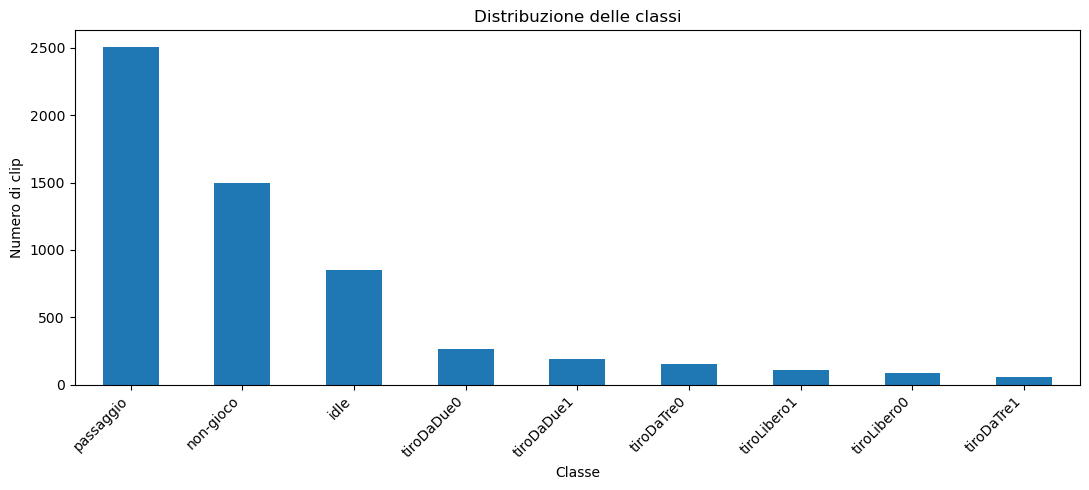

In [3]:
class_distribution = (
    df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)

class_distribution["percent"] = (
    100 * class_distribution["count"] / class_distribution["count"].sum()
).round(2)

display(class_distribution)

ax = class_distribution.plot(
    kind="bar",
    x="label",
    y="count",
    legend=False,
    figsize=(11, 5)
)
ax.set_title("Distribuzione delle classi")
ax.set_xlabel("Classe")
ax.set_ylabel("Numero di clip")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


 ## 3. Distribuzione delle classi per split



 Controlliamo quante clip di ogni classe finiscono in train, validation e test.

split,train,val,test
label,,,
idle,644,93,116
non-gioco,1172,170,155
passaggio,1787,212,506
tiroDaDue0,197,21,48
tiroDaDue1,128,11,50
tiroDaTre0,111,12,29
tiroDaTre1,46,3,9
tiroLibero0,62,7,13
tiroLibero1,89,11,11


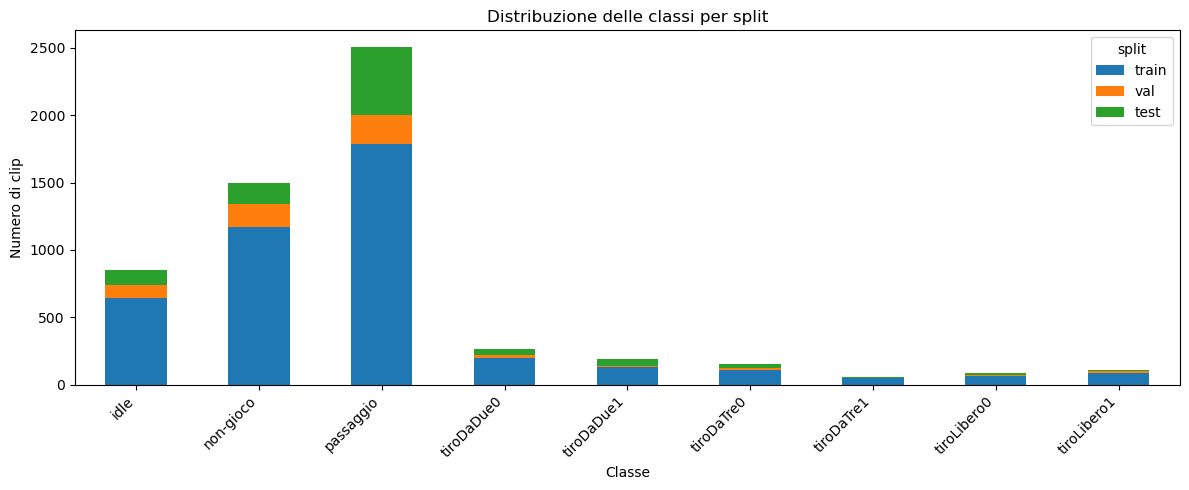

In [4]:
split_distribution = pd.crosstab(df["label"], df["split"])

preferred_order = ["train", "val", "test"]
existing_order = [c for c in preferred_order if c in split_distribution.columns]
other_cols = [c for c in split_distribution.columns if c not in existing_order]
split_distribution = split_distribution[existing_order + other_cols]

display(split_distribution)

ax = split_distribution.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5)
)
ax.set_title("Distribuzione delle classi per split")
ax.set_xlabel("Classe")
ax.set_ylabel("Numero di clip")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


 ## 4. Controllo data leakage per `video_id`



 Lo stesso `video_id` non dovrebbe comparire in più split.

In [5]:
video_split_check = (
    df.groupby("video_id")["split"]
    .nunique()
    .reset_index(name="num_splits")
)

leakage_videos = video_split_check[video_split_check["num_splits"] > 1]

video_split_table = (
    df.groupby(["video_id", "split"])
    .size()
    .reset_index(name="num_clips")
    .sort_values(["video_id", "split"])
)

display(video_split_table)

if len(leakage_videos) == 0:
    print("OK: nessun video_id compare in più split.")
else:
    print("ATTENZIONE: alcuni video_id compaiono in più split.")
    display(leakage_videos)


,video_id,split,num_clips
0,basket_2nd,train,1128
1,prima_parte,train,534
2,psa_converted,test,937
3,psa_corato,train,1174
4,seconda_parte,val,540
5,video1,train,1400


OK: nessun video_id compare in più split.


 ## 5. Lettura dei metadati reali dei video



 Leggiamo FPS, numero di frame, durata, risoluzione e stato di leggibilità di ogni clip.



 Per una prova veloce impostare `MAX_CLIPS_TO_ANALYZE = 500`.

 Per l'analisi finale lasciare `None`.

In [6]:
MAX_CLIPS_TO_ANALYZE = None

if MAX_CLIPS_TO_ANALYZE is None:
    df_to_analyze = df.copy()
else:
    df_to_analyze = df.sample(
        n=min(MAX_CLIPS_TO_ANALYZE, len(df)),
        random_state=42
    ).copy()


def read_video_metadata(relative_path):
    video_path = DATASET_ROOT / relative_path

    info = {
        "file_exists": video_path.exists(),
        "readable": False,
        "fps": np.nan,
        "num_frames": np.nan,
        "duration_seconds": np.nan,
        "width": np.nan,
        "height": np.nan,
    }

    if not video_path.exists():
        return info

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        return info

    fps = cap.get(cv2.CAP_PROP_FPS)
    num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()

    info["readable"] = True
    info["fps"] = fps
    info["num_frames"] = num_frames
    info["duration_seconds"] = num_frames / fps if fps and fps > 0 else np.nan
    info["width"] = width
    info["height"] = height

    return info


rows = []

for row in tqdm(df_to_analyze.itertuples(index=False), total=len(df_to_analyze)):
    video_info = read_video_metadata(row.path)
    video_info.update({
        "clip_id": row.clip_id,
        "path": row.path,
        "video_id": row.video_id,
        "label": row.label,
        "split": row.split,
        "start_time": row.start_time,
        "end_time": row.end_time,
        "duration_from_manifest": row.duration_from_manifest,
    })
    rows.append(video_info)

metadata_df = pd.DataFrame(rows)

print(f"Clip analizzate: {len(metadata_df)}")
display(metadata_df.head())


100%|██████████| 5713/5713 [00:54<00:00, 105.30it/s]

Clip analizzate: 5713


,file_exists,readable,fps,num_frames,duration_seconds,width,height,clip_id,path,video_id,label,split,start_time,end_time,duration_from_manifest
0,True,True,29.97003,38,1.267933,1920,1080,clip_000000,train/passaggio/clip_000000.mp4,basket_2nd,passaggio,train,7.170000,8.430000,1.260000
1,True,True,29.97003,16,0.533867,1920,1080,clip_000001,train/passaggio/clip_000001.mp4,basket_2nd,passaggio,train,14.870000,15.390000,0.520000
2,True,True,29.97003,78,2.602600,1920,1080,clip_000002,train/non-gioco/clip_000002.mp4,basket_2nd,non-gioco,train,18.016190,20.614757,2.598567
3,True,True,29.97003,50,1.668333,1920,1080,clip_000003,train/non-gioco/clip_000003.mp4,basket_2nd,non-gioco,train,20.130861,21.818435,1.687573
4,True,True,29.97003,44,1.468133,1920,1080,clip_000004,train/tiroDaDue0/clip_000004.mp4,basket_2nd,tiroDaDue0,train,33.720000,35.160000,1.440000


 ## 6. Controlli tecnici sui file



 Verifichiamo file mancanti, video non leggibili e clip con valori non validi.

In [7]:
missing_files = metadata_df[metadata_df["file_exists"] == False]

unreadable_files = metadata_df[
    (metadata_df["file_exists"] == True) &
    (metadata_df["readable"] == False)
]

invalid_duration = metadata_df[
    (metadata_df["readable"] == True) &
    (
        (metadata_df["duration_seconds"].isna()) |
        (metadata_df["duration_seconds"] <= 0) |
        (metadata_df["num_frames"] <= 0) |
        (metadata_df["fps"] <= 0)
    )
]

print("File mancanti:", len(missing_files))
print("File non leggibili:", len(unreadable_files))
print("Clip con durata/FPS/frame non validi:", len(invalid_duration))

if len(missing_files) > 0:
    display(missing_files[["clip_id", "label", "split", "path"]].head(20))

if len(unreadable_files) > 0:
    display(unreadable_files[["clip_id", "label", "split", "path"]].head(20))

if len(invalid_duration) > 0:
    display(invalid_duration[[
        "clip_id", "label", "split", "fps",
        "num_frames", "duration_seconds", "path"
    ]].head(20))


File mancanti: 0
File non leggibili: 0
Clip con durata/FPS/frame non validi: 0


 ## 7. Statistiche temporali per classe



 Analizziamo durata e numero di frame per ogni classe.

In [8]:
valid_metadata = metadata_df[metadata_df["readable"] == True].copy()

duration_stats_by_class = (
    valid_metadata
    .groupby("label")
    .agg(
        num_clips=("clip_id", "count"),
        duration_mean=("duration_seconds", "mean"),
        duration_median=("duration_seconds", "median"),
        duration_min=("duration_seconds", "min"),
        duration_max=("duration_seconds", "max"),
        frames_mean=("num_frames", "mean"),
        frames_min=("num_frames", "min"),
        frames_max=("num_frames", "max"),
        fps_median=("fps", "median"),
    )
    .round(3)
    .sort_values("num_clips", ascending=False)
)

display(duration_stats_by_class)


,num_clips,duration_mean,duration_median,duration_min,duration_max,frames_mean,frames_min,frames_max,fps_median
label,,,,,,,,,
passaggio,2505,0.504,0.467,0.133,2.042,14.392,4,50,29.97
non-gioco,1497,2.243,2.208,0.125,5.005,63.699,3,150,29.97
idle,853,0.719,0.534,0.133,2.502,20.547,4,75,29.97
tiroDaDue0,266,1.280,1.268,0.300,2.636,36.876,9,79,29.97
tiroDaDue1,189,1.333,1.268,0.292,2.769,38.005,7,83,29.97
tiroDaTre0,152,1.875,1.835,0.917,3.170,53.678,22,95,29.97
tiroLibero1,111,1.703,1.568,1.083,3.637,48.099,26,109,29.97
tiroLibero0,82,1.880,1.919,0.542,3.003,52.976,13,90,29.97
tiroDaTre1,58,1.753,1.702,1.001,3.542,49.707,30,85,29.97


/var/folders/qv/6h01n8hn0ts9lnx_7fdq337m0000gn/T/ipykernel_67799/2969392973.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(duration_data, labels=labels, showfliers=False)


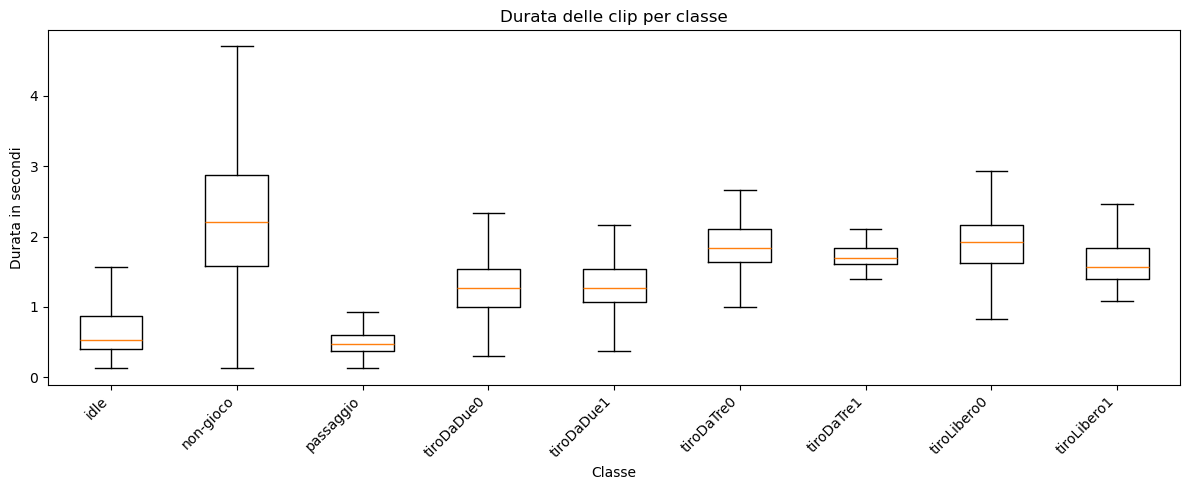

In [9]:
labels = sorted(valid_metadata["label"].unique())

duration_data = [
    valid_metadata.loc[valid_metadata["label"] == label, "duration_seconds"].dropna()
    for label in labels
]

plt.figure(figsize=(12, 5))
plt.boxplot(duration_data, labels=labels, showfliers=False)
plt.title("Durata delle clip per classe")
plt.xlabel("Classe")
plt.ylabel("Durata in secondi")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


/var/folders/qv/6h01n8hn0ts9lnx_7fdq337m0000gn/T/ipykernel_67799/1741096342.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(frame_data, labels=labels, showfliers=False)


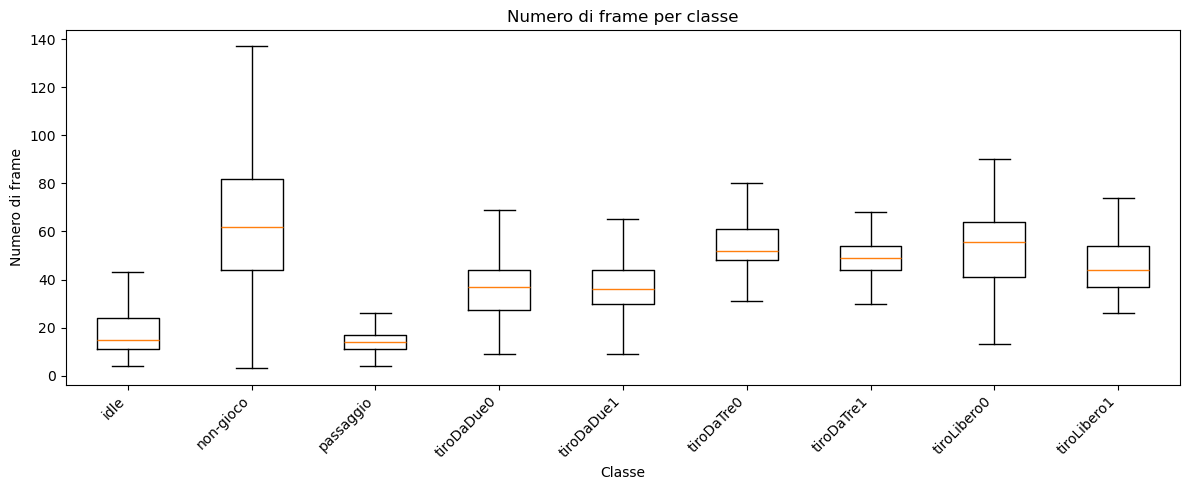

In [10]:
frame_data = [
    valid_metadata.loc[valid_metadata["label"] == label, "num_frames"].dropna()
    for label in labels
]

plt.figure(figsize=(12, 5))
plt.boxplot(frame_data, labels=labels, showfliers=False)
plt.title("Numero di frame per classe")
plt.xlabel("Classe")
plt.ylabel("Numero di frame")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


 ## 8. Clip molto corte e molto lunghe



 Le clip molto corte possono essere corrette, soprattutto per i passaggi, ma è utile controllarle.

In [11]:
SHORT_THRESHOLD_SECONDS = 0.5
LONG_THRESHOLD_SECONDS = 5.0

short_clips = valid_metadata[
    valid_metadata["duration_seconds"] < SHORT_THRESHOLD_SECONDS
].sort_values("duration_seconds")

long_clips = valid_metadata[
    valid_metadata["duration_seconds"] > LONG_THRESHOLD_SECONDS
].sort_values("duration_seconds", ascending=False)

print(f"Clip più corte di {SHORT_THRESHOLD_SECONDS}s:", len(short_clips))
print(f"Clip più lunghe di {LONG_THRESHOLD_SECONDS}s:", len(long_clips))

print("\nEsempi di clip corte:")
display(short_clips[[
    "clip_id", "label", "split",
    "duration_seconds", "num_frames", "path"
]].head(20))

print("\nEsempi di clip lunghe:")
display(long_clips[[
    "clip_id", "label", "split",
    "duration_seconds", "num_frames", "path"
]].head(20))


Clip più corte di 0.5s: 1744
Clip più lunghe di 5.0s: 1

Esempi di clip corte:


,clip_id,label,split,duration_seconds,num_frames,path
5712,clip_005720,non-gioco,train,0.125000,3,train/non-gioco/clip_005720.mp4
2636,clip_002640,passaggio,train,0.133467,4,train/passaggio/clip_002640.mp4
1957,clip_001960,idle,test,0.133467,4,test/idle/clip_001960.mp4
3753,clip_003759,passaggio,train,0.133467,4,train/passaggio/clip_003759.mp4
5362,clip_005370,passaggio,train,0.166667,4,train/passaggio/clip_005370.mp4
5612,clip_005620,passaggio,train,0.166667,4,train/passaggio/clip_005620.mp4
4395,clip_004401,passaggio,train,0.166667,4,train/passaggio/clip_004401.mp4
5407,clip_005415,passaggio,train,0.166667,4,train/passaggio/clip_005415.mp4
4487,clip_004493,passaggio,train,0.166667,4,train/passaggio/clip_004493.mp4
5463,clip_005471,idle,train,0.166667,4,train/idle/clip_005471.mp4



Esempi di clip lunghe:


,clip_id,label,split,duration_seconds,num_frames,path
751,clip_000753,non-gioco,train,5.005,150,train/non-gioco/clip_000753.mp4
